In [1]:
import pandas as pd

df = pd.read_csv('Resume.csv')

In [2]:
print(df.head())
print(df.info())

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null

In [3]:
import re

df = df.drop(columns=['ID', 'Resume_html'])

def clean_text(text):
    text = re.sub(r'http\S+\s*', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

df['Cleaned_Resume'] = df['Resume_str'].apply(clean_text)

In [4]:
df.head()

,Resume_str,Category,Cleaned_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...


In [6]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


C:\Users\cyberguard\AppData\Local\Temp\ipykernel_35572\3990868194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')


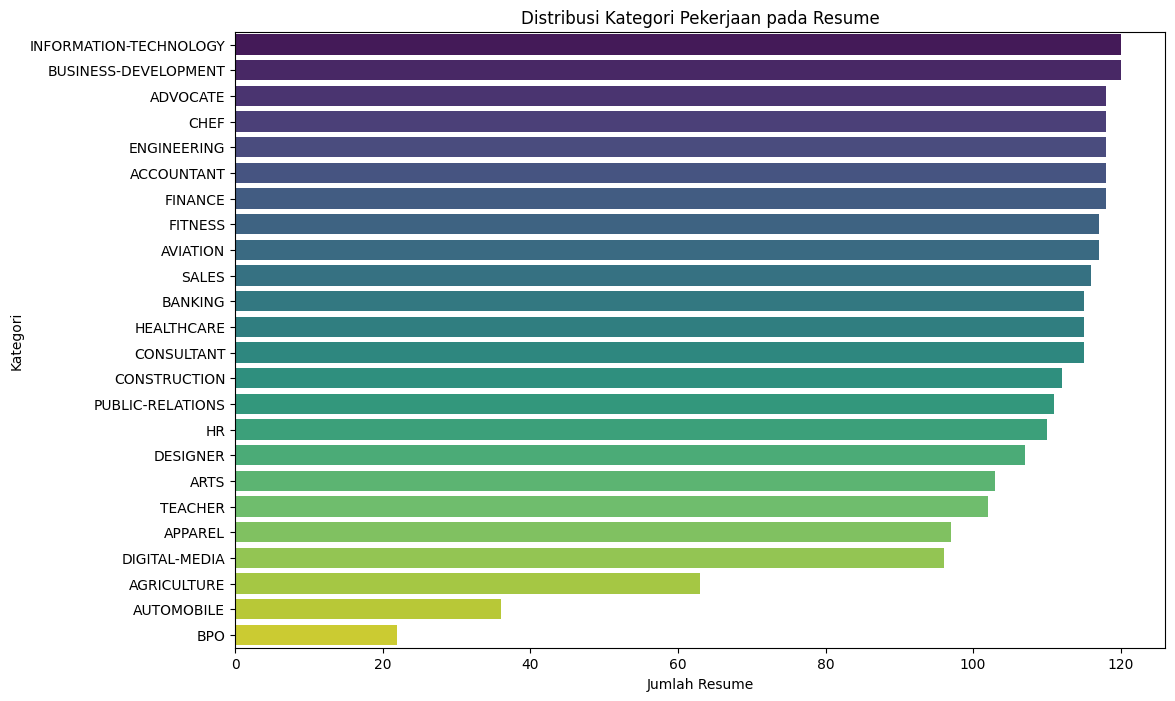

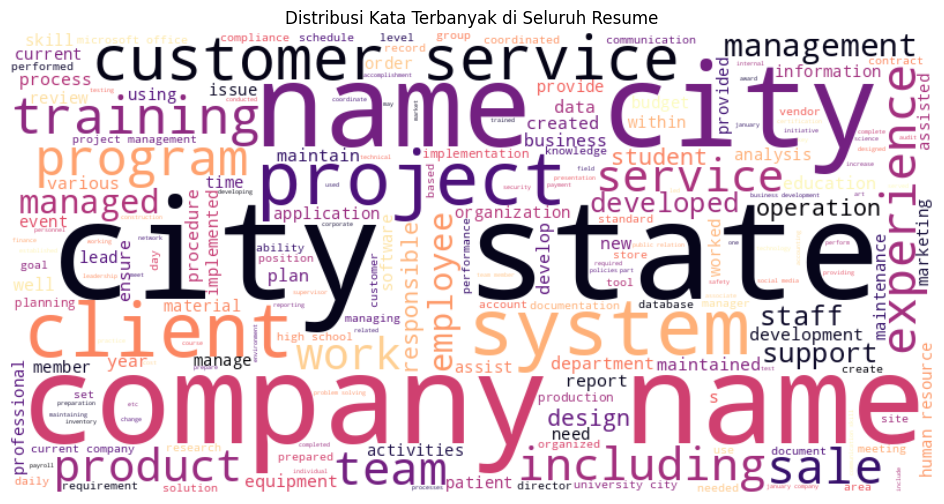

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.figure(figsize=(12, 8))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribusi Kategori Pekerjaan pada Resume')
plt.xlabel('Jumlah Resume')
plt.ylabel('Kategori')
plt.show()

all_text = " ".join(df['Cleaned_Resume'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Distribusi Kata Terbanyak di Seluruh Resume')
plt.show()

In [9]:
%pip install nltk

  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.6 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 10.1 MB/s  0:00:00
Using cached click-8.4.1-py3-none-any.whl (116 kB)

   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   ---

In [5]:
import nltk
from nltk.corpus import stopwords

# Mengunduh kamus stopwords dari NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Menambahkan kata-kata 'sampah' spesifik yang kita temukan dari Word Cloud
custom_stopwords = {'city', 'state', 'name', 'company', 'zip', 'email', 'phone', 'address'}
stop_words = stop_words.union(custom_stopwords)

# Fungsi untuk menghapus stopwords
def remove_stopwords(text):
    words = text.split()
    # Hanya simpan kata yang tidak ada di daftar stop_words
    clean_words = [word for word in words if word not in stop_words]
    return ' '.join(clean_words)

# Terapkan ke kolom resume yang sebelumnya sudah dibersihkan
df['Cleaned_Resume'] = df['Cleaned_Resume'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cyberguard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


C:\Users\cyberguard\AppData\Local\Temp\ipykernel_25776\3990868194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')


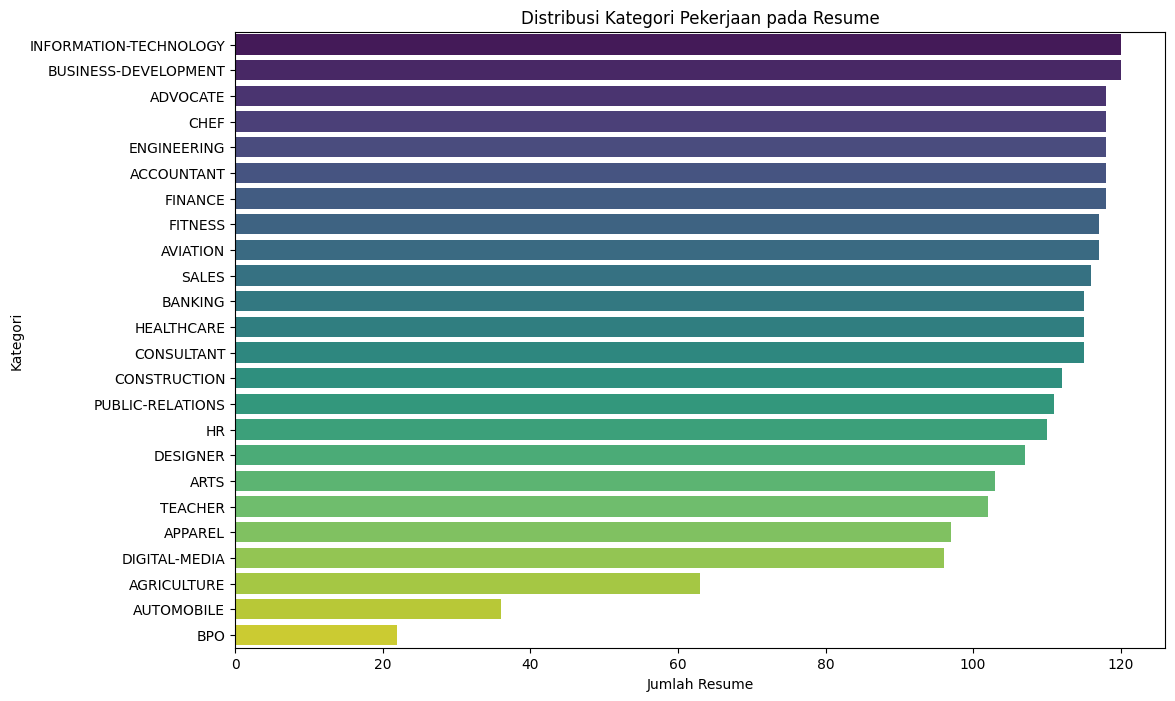

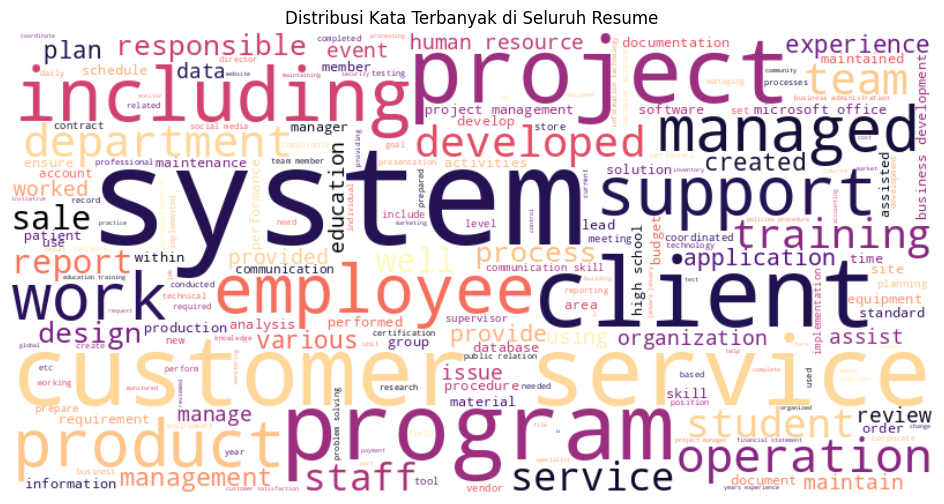

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

plt.figure(figsize=(12, 8))
sns.countplot(y=df['Category'], order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribusi Kategori Pekerjaan pada Resume')
plt.xlabel('Jumlah Resume')
plt.ylabel('Kategori')
plt.show()

all_text = " ".join(df['Cleaned_Resume'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Distribusi Kata Terbanyak di Seluruh Resume')
plt.show()

Statistik Deskriptif Jumlah Kata per CV:
count    2484.000000
mean      568.982287
std       262.168069
min         0.000000
25%       458.000000
50%       530.000000
75%       656.000000
max      3551.000000
Name: Word_Count, dtype: float64


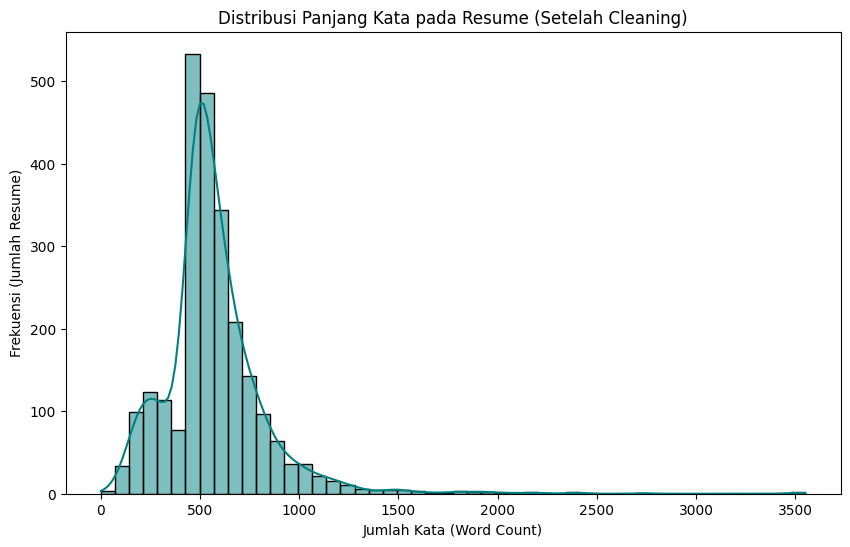

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung jumlah kata untuk setiap resume yang sudah dibersihkan
df['Word_Count'] = df['Cleaned_Resume'].apply(lambda x: len(str(x).split()))

# 2. Menampilkan Statistik Deskriptif (Wajib untuk presentasi)
print("Statistik Deskriptif Jumlah Kata per CV:")
print(df['Word_Count'].describe())

# 3. Membuat Visualisasi Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Word_Count', bins=50, kde=True, color='teal')
plt.title('Distribusi Panjang Kata pada Resume (Setelah Cleaning)')
plt.xlabel('Jumlah Kata (Word Count)')
plt.ylabel('Frekuensi (Jumlah Resume)')
plt.show()

In [11]:
%pip install tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Label Encoding (Mengubah Kategori Text -> Angka 0 hingga 23)
encoder = LabelEncoder()
y = encoder.fit_transform(df['Category'])

# Menyimpan nama kelas asli (sangat penting untuk aplikasi HRD nanti)
class_names = encoder.classes_
print(f"Total Kategori Pekerjaan: {len(class_names)}")

# 2. Train-Test Split (Dengan Stratified Sampling)
# Membagi 80% data untuk belajar (Train) dan 20% untuk ujian (Test)
X = df['Cleaned_Resume']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Training: {len(X_train)}")
print(f"Jumlah Data Testing: {len(X_test)}")

# 3. Tokenization & Padding (Berdasarkan insight Histogram kita)
MAX_WORDS = 10000 # Model akan mengingat 10.000 kata yang paling sering muncul
MAX_LENGTH = 800  # Kita potong panjang CV maksimal di 800 kata demi efisiensi

# Membuat kamus kata HANYA dari data training (untuk mencegah kebocoran informasi / data leakage)
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Mengubah teks CV menjadi urutan angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Menyamakan panjang semua matriks menjadi tepat 800 kolom (Padding)
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

print("Bentuk matriks X_train_padded (Jumlah Data, Panjang Kata):", X_train_padded.shape)

Total Kategori Pekerjaan: 24
Jumlah Data Training: 1987
Jumlah Data Testing: 497
Bentuk matriks X_train_padded (Jumlah Data, Panjang Kata): (1987, 800)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

# Konfigurasi Dimensi Model
VOCAB_SIZE = 10000     
EMBEDDING_DIM = 128    
MAX_LENGTH = 800       
NUM_CLASSES = 24       

# Inisialisasi Arsitektur Model Sequential
model = Sequential()

# Layer 0: Input Layer (Wajib untuk Keras versi terbaru)
model.add(Input(shape=(MAX_LENGTH,)))

# Layer 1: Embedding Layer
model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))

# Layer 2: LSTM Layer
model.add(LSTM(units=64, return_sequences=False))

# Layer 3: Dropout Layer
model.add(Dropout(rate=0.5))

# Layer 4: Output Layer (Dense)
model.add(Dense(units=NUM_CLASSES, activation='softmax'))

# Kompilasi Model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Menampilkan struktur arsitektur model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 800, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330,968 (5.08 MB)

 Trainable params: 1,330,968 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# Inisialisasi Early Stopping (Langkah 10: Dynamic Tuning)
# Menghentikan training jika 'val_loss' (error pada data ujian) tidak membaik selama 3 putaran berturut-turut
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# Memulai Proses Training (Langkah 11)
print("Memulai proses pelatihan AI. Mohon tunggu, proses ini akan memakan waktu pada CPU...")

history = model.fit(
    X_train_padded, 
    y_train, 
    epochs=15,             # Batas maksimal putaran belajar
    batch_size=32,         # Memproses 32 CV sekaligus sebelum mengupdate bobot
    validation_data=(X_test_padded, y_test), # Langsung menguji dengan data testing
    callbacks=[early_stop] # Memasukkan fungsi rem otomatis
)

Memulai proses pelatihan AI. Mohon tunggu, proses ini akan memakan waktu pada CPU...
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 302ms/step - accuracy: 0.0382 - loss: 3.1687 - val_accuracy: 0.0402 - val_loss: 3.1579
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 289ms/step - accuracy: 0.0689 - loss: 3.1542 - val_accuracy: 0.0624 - val_loss: 3.1471
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 265ms/step - accuracy: 0.0835 - loss: 3.1481 - val_accuracy: 0.0523 - val_loss: 3.1496
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.0986 - loss: 3.1312 - val_accuracy: 0.0543 - val_loss: 3.1434
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step - accuracy: 0.1017 - loss: 3.1148 - val_accuracy: 0.0604 - val_loss: 3.1388
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 260ms/step - accuracy: 0.1107 - loss: 3.0747 - val_accuracy: 0.0543 - val_loss: 3.1368
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.1122 - loss: 3.0223 - val_accuracy: 0.0563 - val_loss: 3.1329
Epoch 8/15
6

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step
Classification Report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.00      0.00      0.00        24
              ADVOCATE       0.00      0.00      0.00        24
           AGRICULTURE       0.00      0.00      0.00        13
               APPAREL       0.00      0.00      0.00        19
                  ARTS       0.00      0.00      0.00        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.00      0.00      0.00        24
               BANKING       0.05      0.91      0.09        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.00      0.00      0.00        24
                  CHEF       0.00      0.00      0.00        24
          CONSTRUCTION       0.10      0.05      0.06        22
            CONSULTANT       0.22      0.09      0.12        23
              DESIGNER       0.00      

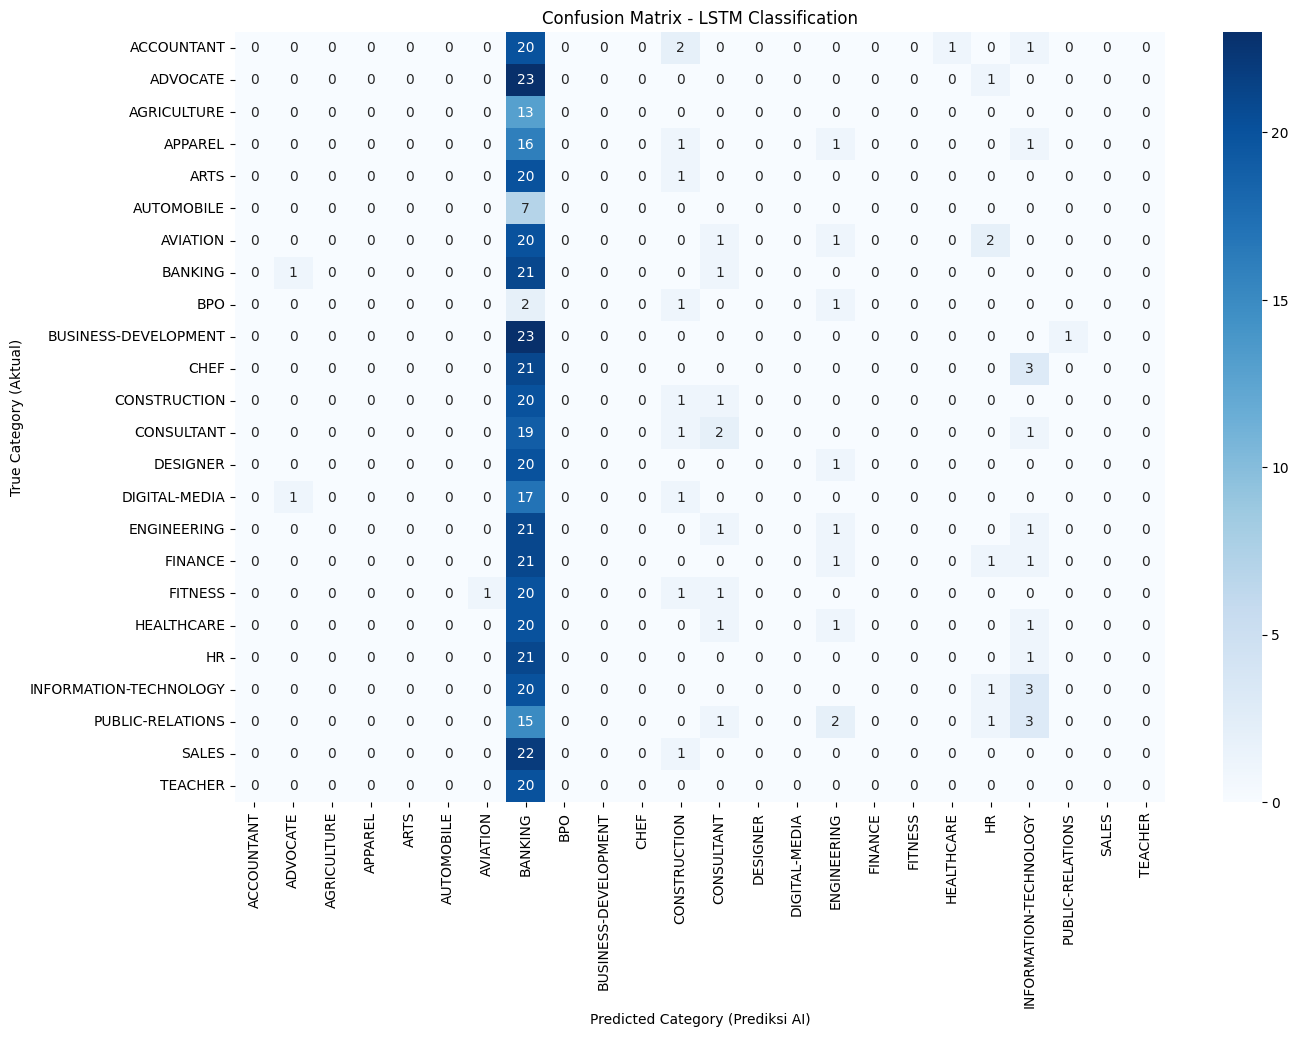

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions from the test data
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Output Classification Report (Accuracy, Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# 2. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - LSTM Classification')
plt.ylabel('True Category (Aktual)')
plt.xlabel('Predicted Category (Prediksi AI)')
plt.xticks(rotation=90)
plt.show()

In [17]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Menghitung Class Weights (Mengatasi Ketidakseimbangan Data)
class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(y_train), 
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))

# 2. Inisialisasi Arsitektur Bidirectional LSTM + Pooling
model_tuned = Sequential()
model_tuned.add(Input(shape=(MAX_LENGTH,)))
model_tuned.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))

# Bidirectional: Membaca teks dari depan dan dari belakang
model_tuned.add(Bidirectional(LSTM(units=64, return_sequences=True)))

# Mengambil intisari fitur (kata kunci) terpenting dari seluruh urutan teks
model_tuned.add(GlobalMaxPooling1D())

model_tuned.add(Dropout(rate=0.5))
model_tuned.add(Dense(units=NUM_CLASSES, activation='softmax'))

# Kompilasi Model
model_tuned.compile(
    loss='sparse_categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

# 3. Proses Pelatihan Ulang (Training dengan Class Weights)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_tuned = model_tuned.fit(
    X_train_padded, 
    y_train, 
    epochs=15,
    batch_size=32,
    validation_data=(X_test_padded, y_test),
    class_weight=class_weights_dict,  # Memasukkan bobot penyeimbang
    callbacks=[early_stop]
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 587ms/step - accuracy: 0.0594 - loss: 3.1701 - val_accuracy: 0.2455 - val_loss: 3.1318
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 535ms/step - accuracy: 0.2597 - loss: 3.0028 - val_accuracy: 0.2575 - val_loss: 2.7631
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 553ms/step - accuracy: 0.3770 - loss: 2.5070 - val_accuracy: 0.5573 - val_loss: 2.0536
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 570ms/step - accuracy: 0.5440 - loss: 1.9679 - val_accuracy: 0.6901 - val_loss: 1.6046
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 550ms/step - accuracy: 0.6306 - loss: 1.6694 - val_accuracy: 0.7002 - val_loss: 1.3979
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 560ms/step - accuracy: 0.6356 - loss: 1.5945 - val_accuracy: 0.7264 - val_loss: 1.3120
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 573ms/step - accuracy: 0.7484 - loss: 1.1926 - val_accuracy: 0.7606 - val_loss: 1.0894
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 37s 579ms/step - accuracy: 0.8228 - loss: 0.9518 - val_accu

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step
Classification Report (Tuned Model):
                        precision    recall  f1-score   support

            ACCOUNTANT       0.96      1.00      0.98        24
              ADVOCATE       0.88      0.88      0.88        24
           AGRICULTURE       0.56      0.69      0.62        13
               APPAREL       0.46      0.32      0.38        19
                  ARTS       0.67      0.48      0.56        21
            AUTOMOBILE       0.50      0.43      0.46         7
              AVIATION       0.95      0.79      0.86        24
               BANKING       0.93      0.57      0.70        23
                   BPO       0.50      0.25      0.33         4
  BUSINESS-DEVELOPMENT       0.66      0.96      0.78        24
                  CHEF       0.90      0.79      0.84        24
          CONSTRUCTION       0.91      0.91      0.91        22
            CONSULTANT       0.81      0.96      0.88        23
              DESIGNER   

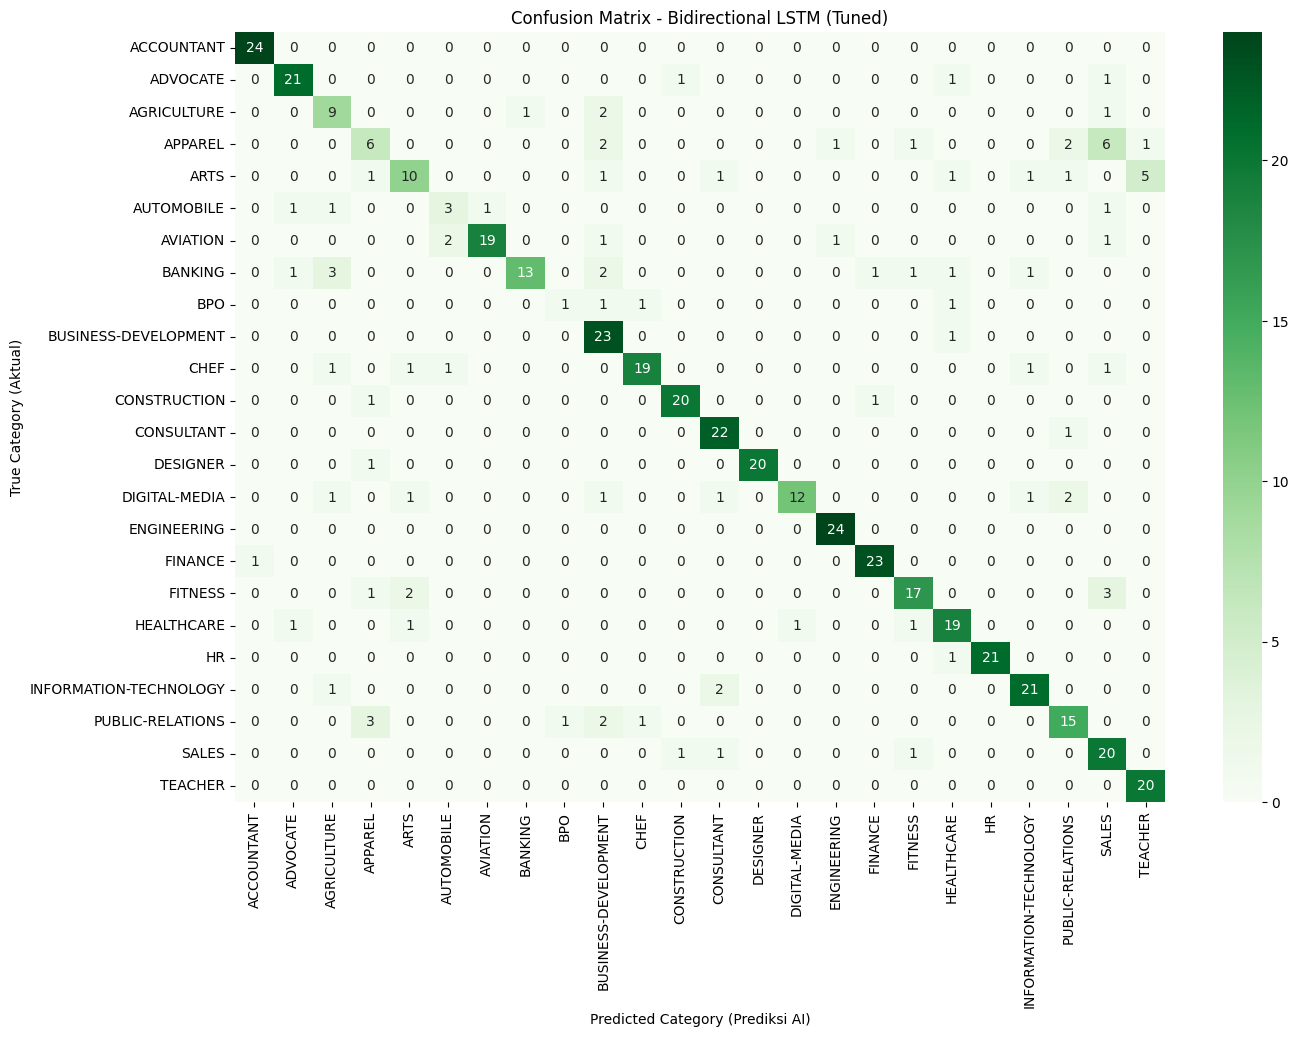

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions using the tuned model
y_pred_probs_tuned = model_tuned.predict(X_test_padded)
y_pred_tuned = np.argmax(y_pred_probs_tuned, axis=1)

# Generate Classification Report
print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, target_names=class_names, zero_division=0))

# Generate Confusion Matrix Visualization
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(15, 10))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Bidirectional LSTM (Tuned)')
plt.ylabel('True Category (Aktual)')
plt.xlabel('Predicted Category (Prediksi AI)')
plt.xticks(rotation=90)
plt.show()

In [19]:
model_tuned.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 800, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 800, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,145,738 (15.81 MB)

 Trainable params: 1,381,912 (5.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,763,826 (10.54 MB)

In [21]:
import pickle

# 1. Menyimpan Model AI (Menggunakan format .keras sesuai standar Keras 3 terbaru)
model_tuned.save('model_cv_lstm_tuned.keras')
print("✅ Model AI berhasil disimpan: model_cv_lstm_tuned.keras")

# 2. Menyimpan Tokenizer (Kamus Kata ke Angka)
with open('tokenizer_cv.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer berhasil disimpan: tokenizer_cv.pkl")

# 3. Menyimpan Label Encoder (Memperbaiki pemanggilan variabel 'encoder')
with open('label_encoder_cv.pkl', 'wb') as f:
    pickle.dump(encoder, f)
print("✅ Label Encoder berhasil disimpan: label_encoder_cv.pkl")

✅ Model AI berhasil disimpan: model_cv_lstm_tuned.keras
✅ Tokenizer berhasil disimpan: tokenizer_cv.pkl
✅ Label Encoder berhasil disimpan: label_encoder_cv.pkl
